# EDA - Reseñas para Análisis de Sentimiento
Dataset: ~1 millón de reseñas de críticos de cine/TV

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

DATA_PATH = 'data/datos_proyecto.csv'
CHUNK_SIZE = 100

## 1. Lectura por chunks

In [2]:
chunks = []

for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print(f'Total filas cargadas: {len(df):,}')
df.head()

Total filas cargadas: 999


,id,reviewId,creationDate,criticName,isTopCritic,originalScore,reviewState,publicatioName,reviewText,scoreSentiment,reviewUrl
0,beavers,1145982,2003-05-23,Ivan M. Lincoln,False,3.5/4,fresh,Deseret News (Salt Lake City),Timed to be just long enough for most youngste...,POSITIVE,http://www.deseretnews.com/article/700003233/B...
1,blood_mask,1636744,2007-06-02,The Foywonder,False,1/5,rotten,Dread Central,It doesn't matter if a movie costs 300 million...,NEGATIVE,http://www.dreadcentral.com/index.php?name=Rev...
2,city_hunter_shinjuku_private_eyes,2590987,2019-05-28,Reuben Baron,False,NaN,fresh,CBR,The choreography is so precise and lifelike at...,POSITIVE,https://www.cbr.com/city-hunter-shinjuku-priva...
3,city_hunter_shinjuku_private_eyes,2558908,2019-02-14,Matt Schley,False,2.5/5,rotten,Japan Times,The film's out-of-touch attempts at humor may ...,NEGATIVE,https://www.japantimes.co.jp/culture/2019/02/0...
4,dangerous_men_2015,2504681,2018-08-29,Pat Padua,False,NaN,fresh,DCist,Its clumsy determination is endearing and some...,POSITIVE,http://dcist.com/2015/11/out_of_frame_dangerou...


## 2. Eliminar registros sin reseña

In [3]:
print(f'Filas antes de limpiar: {len(df):,}')
print(f'Valores nulos en reviewText: {df["reviewText"].isna().sum():,}')

# Eliminar nulos y strings vacíos/solo espacios
df = df[df['reviewText'].notna()]
df = df[df['reviewText'].str.strip() != '']

print(f'Filas después de limpiar: {len(df):,}')

Filas antes de limpiar: 999
Valores nulos en reviewText: 90
Filas después de limpiar: 909


## 3. Selección de columnas relevantes

In [4]:
COLS = ['reviewId', 'creationDate', 'criticName', 'isTopCritic',
        'reviewState', 'reviewText', 'scoreSentiment']

df = df[COLS].copy()

# Conversión de tipos
df['creationDate'] = pd.to_datetime(df['creationDate'], errors='coerce')
df['isTopCritic'] = df['isTopCritic'].astype(bool)

print(df.dtypes)
df.head()

reviewId                   int64
creationDate      datetime64[us]
criticName                   str
isTopCritic                 bool
reviewState                  str
reviewText                   str
scoreSentiment               str
dtype: object


,reviewId,creationDate,criticName,isTopCritic,reviewState,reviewText,scoreSentiment
0,1145982,2003-05-23,Ivan M. Lincoln,False,fresh,Timed to be just long enough for most youngste...,POSITIVE
1,1636744,2007-06-02,The Foywonder,False,rotten,It doesn't matter if a movie costs 300 million...,NEGATIVE
2,2590987,2019-05-28,Reuben Baron,False,fresh,The choreography is so precise and lifelike at...,POSITIVE
3,2558908,2019-02-14,Matt Schley,False,rotten,The film's out-of-touch attempts at humor may ...,NEGATIVE
4,2504681,2018-08-29,Pat Padua,False,fresh,Its clumsy determination is endearing and some...,POSITIVE


## 4. Limpieza de la columna reviewText

In [6]:
def clean_review(text: str) -> str:
    """Normaliza una reseña para análisis de sentimiento."""
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)        # quita tags HTML
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  # quita URLs
    text = re.sub(r'[^a-z0-9\s\'.,!?-]', ' ', text)  # solo chars útiles
    text = re.sub(r'\s+', ' ', text).strip()    # colapsa espacios
    return text

df['reviewText_clean'] = df['reviewText'].apply(clean_review)

# Vista comparativa
df[['reviewText', 'reviewText_clean']].head(5)

,reviewText,reviewText_clean
0,Timed to be just long enough for most youngste...,timed to be just long enough for most youngste...
1,It doesn't matter if a movie costs 300 million...,it doesn't matter if a movie costs 300 million...
2,The choreography is so precise and lifelike at...,the choreography is so precise and lifelike at...
3,The film's out-of-touch attempts at humor may ...,the film's out-of-touch attempts at humor may ...
4,Its clumsy determination is endearing and some...,its clumsy determination is endearing and some...


## 5. Estadísticas básicas

In [7]:
# Distribución de sentimiento
print('=== Distribución scoreSentiment ===')
print(df['scoreSentiment'].value_counts())
print(f'\nBalanceo: {df["scoreSentiment"].value_counts(normalize=True).mul(100).round(1).to_dict()}')

=== Distribución scoreSentiment ===
scoreSentiment
POSITIVE    651
NEGATIVE    258
Name: count, dtype: int64

Balanceo: {'POSITIVE': 71.6, 'NEGATIVE': 28.4}


count    909.0
mean      21.9
std        9.7
min        1.0
25%       15.0
50%       22.0
75%       29.0
max       54.0
Name: word_count, dtype: float64


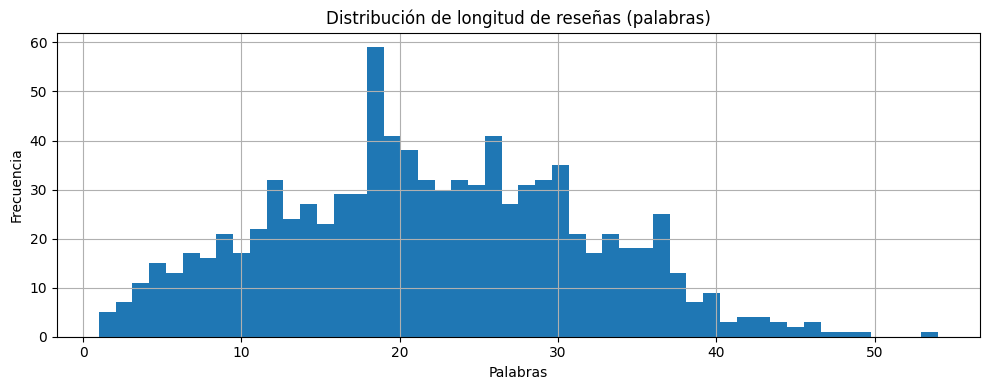

In [8]:
# Longitud de reseñas (en palabras)
df['word_count'] = df['reviewText_clean'].str.split().str.len()

print(df['word_count'].describe().round(1))

df['word_count'].clip(upper=300).hist(bins=50, figsize=(10, 4))
plt.title('Distribución de longitud de reseñas (palabras)')
plt.xlabel('Palabras')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [9]:
# Longitud promedio por sentimiento
df.groupby('scoreSentiment')['word_count'].mean().round(1)

scoreSentiment
NEGATIVE    22.0
POSITIVE    21.9
Name: word_count, dtype: float64

In [10]:
# Resumen final del dataframe limpio
print(f'Shape final: {df.shape}')
df.info()

Shape final: (909, 9)
<class 'pandas.DataFrame'>
Index: 909 entries, 0 to 996
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   reviewId          909 non-null    int64         
 1   creationDate      909 non-null    datetime64[us]
 2   criticName        909 non-null    str           
 3   isTopCritic       909 non-null    bool          
 4   reviewState       909 non-null    str           
 5   reviewText        909 non-null    str           
 6   scoreSentiment    909 non-null    str           
 7   reviewText_clean  909 non-null    str           
 8   word_count        909 non-null    int64         
dtypes: bool(1), datetime64[us](1), int64(2), str(5)
memory usage: 64.8 KB
